In [ ]:
import os
os.cpu_count()

8

In [ ]:
from __future__ import annotations

from pathlib import Path
import os
from concurrent.futures import ProcessPoolExecutor, ThreadPoolExecutor, as_completed

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt

In [ ]:
# Prevent CPU oversubscription (to avoid laptop freeze)

os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"

cv2.setNumThreads(1)

# paths
PROJECT_DIR = Path.cwd()
RAW_DIR = PROJECT_DIR / "data" / "raw"
OUT_DIR = PROJECT_DIR / "data" / "outputs"

OUT_DIR.mkdir(parents=True, exist_ok=True)

VIDEOS = sorted(RAW_DIR.glob("*.mp4"))
if not VIDEOS:
    raise FileNotFoundError(f"No .mp4 videos found in {RAW_DIR}")

print(f"Found {len(VIDEOS)} videos.")
print("Example video:", VIDEOS[0].name)


# workers
CPU_WORKERS = 2
IO_WORKERS = 2

print("Using CPU_WORKERS =", CPU_WORKERS)
print("Using IO_WORKERS  =", IO_WORKERS)


# -oncurrency Helpers

def run_cpu_tasks(func, items):
    """
    Use for heavy per-video processing.
    Always max 2 workers.
    """
    results = []
    with ProcessPoolExecutor(max_workers=CPU_WORKERS) as ex:
        futures = [ex.submit(func, item) for item in items]
        for f in as_completed(futures):
            results.append(f.result())
    return results


def run_io_tasks(func, items):
    """
    Use for saving many images or CSV files.
    """
    with ThreadPoolExecutor(max_workers=IO_WORKERS) as ex:
        futures = [ex.submit(func, item) for item in items]
        for f in as_completed(futures):
            _ = f.result()


Found 11 videos.
Example video: vid_001.mp4
Using CPU_WORKERS = 2
Using IO_WORKERS  = 2


In [ ]:
# display helpers

def show(img, title="", cmap="gray", figsize=(6,6)):
    plt.figure(figsize=figsize)
    plt.imshow(img, cmap=cmap)
    plt.title(title)
    plt.axis("off")
    plt.show()

def show_column(images, titles, figsize=(8, 20)):
    n = len(images)
    plt.figure(figsize=figsize)
    for i, (img, t) in enumerate(zip(images, titles), start=1):
        plt.subplot(n, 1, i)
        plt.imshow(img, cmap="gray")
        plt.title(t)
        plt.axis("off")
    plt.tight_layout()
    plt.show()

def stats(img, name="img"):
    return (f"{name}: min={int(img.min())} max={int(img.max())} "
            f"mean={img.mean():.2f} std={img.std():.2f}")

In [ ]:
# Video Metadata Utility
def read_video_meta(video_path: Path) -> dict:
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        raise RuntimeError(f"Could not open video: {video_path}")

    meta = {
        "name": video_path.name,
        "fps": cap.get(cv2.CAP_PROP_FPS),
        "frame_count": int(cap.get(cv2.CAP_PROP_FRAME_COUNT)),
        "width": int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)),
        "height": int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT)),
    }

    cap.release()
    return meta

Using video: vid_008.mp4
frame_count: 2218
frame_id: 1109


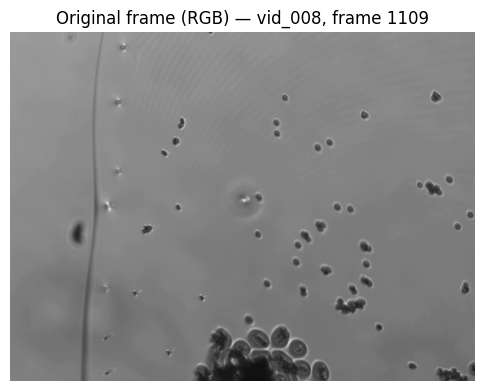

In [ ]:
videos = sorted(RAW_DIR.glob("*.mp4"))
matches = [p for p in videos if "vid_008" in p.stem]
if not matches:
    raise FileNotFoundError(f"vid_008 not found in {RAW_DIR}. Found: {[v.name for v in videos[:10]]}")

video_path = matches[0]
print("Using video:", video_path.name)

cap = cv2.VideoCapture(str(video_path))
frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
cap.release()
print("frame_count:", frame_count)

# pick a representative frame (middle)
frame_id = frame_count // 2
print("frame_id:", frame_id)

cap = cv2.VideoCapture(str(video_path))
cap.set(cv2.CAP_PROP_POS_FRAMES, frame_id)
ret, frame_bgr = cap.read()
cap.release()

if not ret:
    raise RuntimeError(f"Could not read frame {frame_id}")

# show original BGR converted to RGB for correct notebook display
frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(6,6))
plt.imshow(frame_rgb)
plt.title(f"Original frame (RGB) — {video_path.stem}, frame {frame_id}")
plt.axis("off")
plt.show()

gray: min=15 max=253 mean=127.59 std=17.96


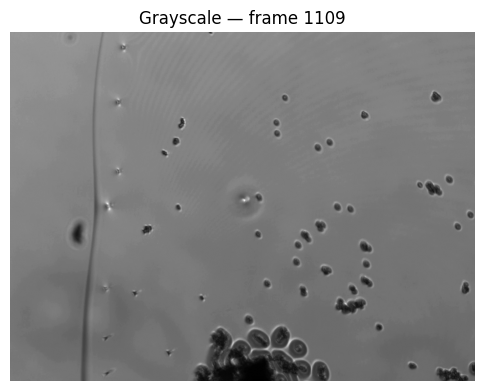

In [ ]:
# convert to grayscale
gray = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2GRAY)

print(stats(gray, "gray"))
show(gray, f"Grayscale — frame {frame_id}")

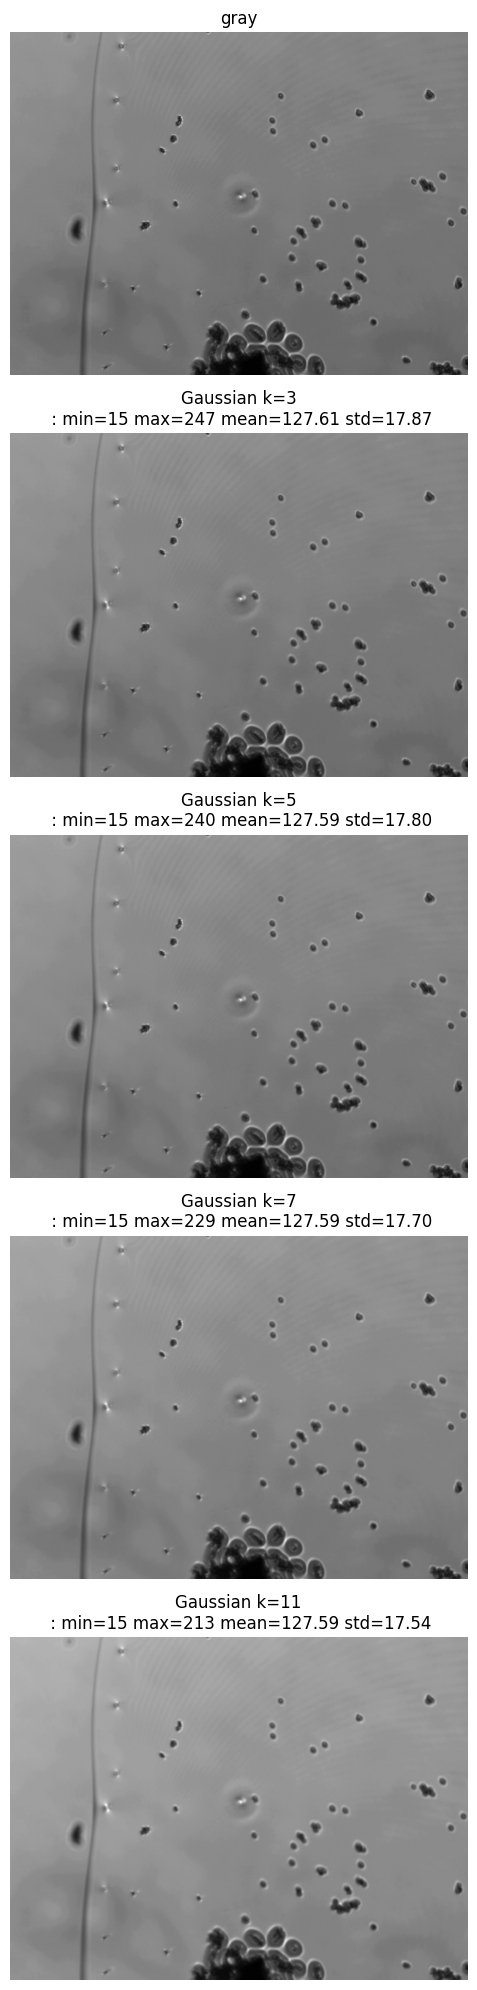

In [ ]:
kernels = [3, 5, 7, 11]  # odd sizes
blurs = []
titles = ["gray"]

for k in kernels:
    b = cv2.GaussianBlur(gray, (k, k), 0)
    blurs.append(b)
    titles.append(f"Gaussian k={k}\n{stats(b, ' ')}")

show_column([gray] + blurs, titles)

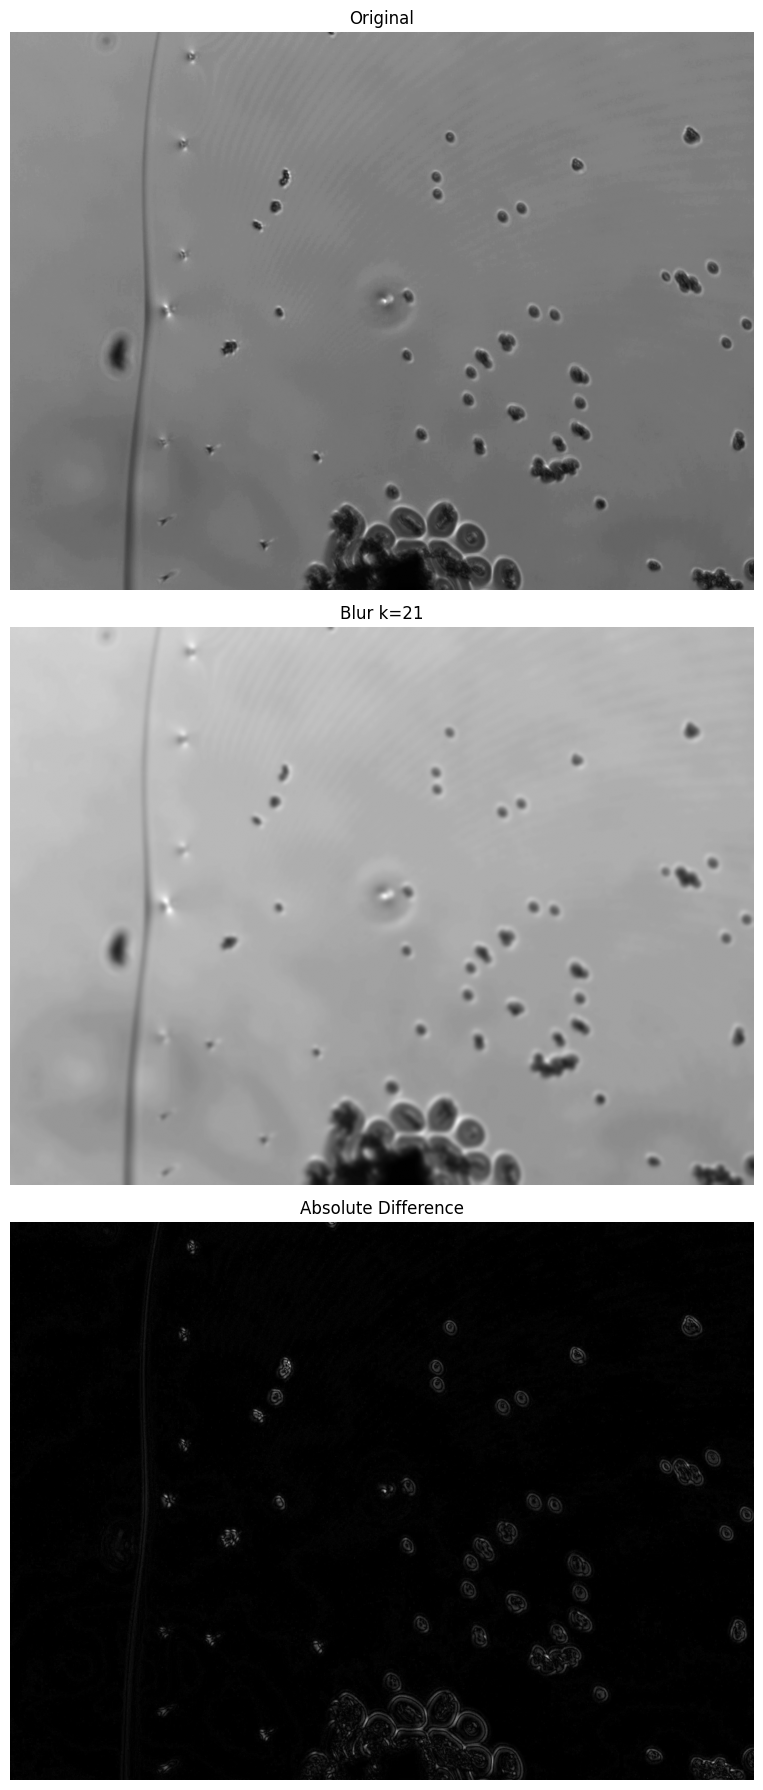

difference: min=0 max=99 mean=1.23 std=2.98


In [ ]:
k = 21
blur = cv2.GaussianBlur(gray, (k,k), 0)

diff = cv2.absdiff(gray, blur)

show_column(
    [gray, blur, diff],
    ["Original", f"Blur k={k}", "Absolute Difference"],
    figsize=(8, 18)
)

print(stats(diff, "difference"))

In [ ]:
# Correlation between original gray image and blurred image
gray_flat = gray.astype(np.float32).ravel()
blur_flat = blur.astype(np.float32).ravel()

corr_gray_blur = np.corrcoef(gray_flat, blur_flat)[0, 1]
print(f"Correlation(gray, blur) for k={k}: {corr_gray_blur:.6f}")

Correlation(gray, blur) for k=21: 0.984330


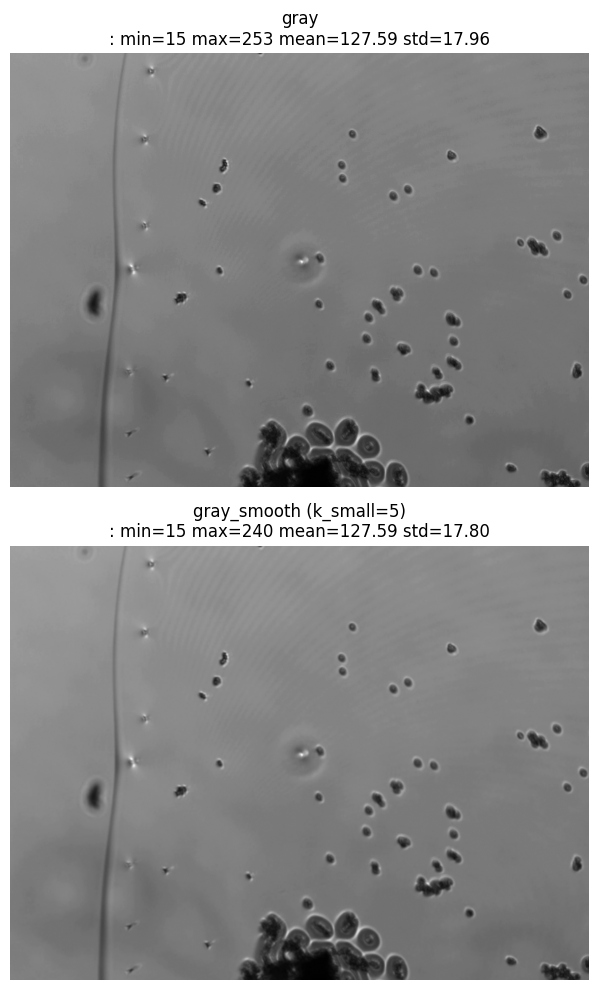

In [ ]:
k_small = 5
gray_smooth = cv2.GaussianBlur(gray, (k_small, k_small), 0)

show_column(
    [gray, gray_smooth],
    [f"gray\n{stats(gray,'')}", f"gray_smooth (k_small={k_small})\n{stats(gray_smooth,'')}"],
    figsize=(8, 10)
)

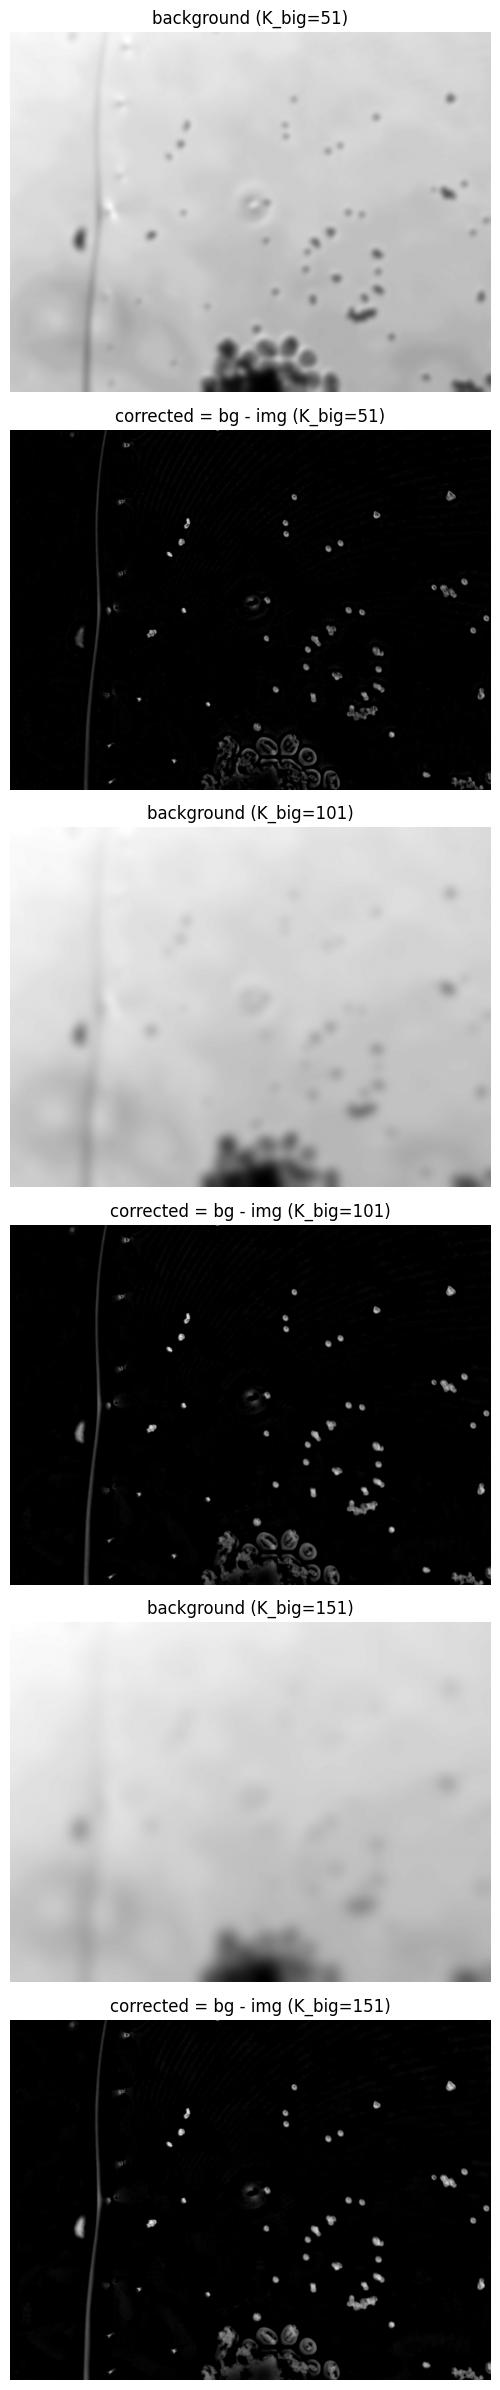

In [ ]:
# background estimation
K_big_list = [51, 101, 151]   # try a few
images = []
titles = []

for K_big in K_big_list:
    background = cv2.GaussianBlur(gray_smooth, (K_big, K_big), 0)
    corrected = cv2.subtract(background, gray_smooth)  # dark -> bright

    images.extend([background, corrected])
    titles.extend([f"background (K_big={K_big})", f"corrected = bg - img (K_big={K_big})"])

show_column(images, titles, figsize=(8, 24))

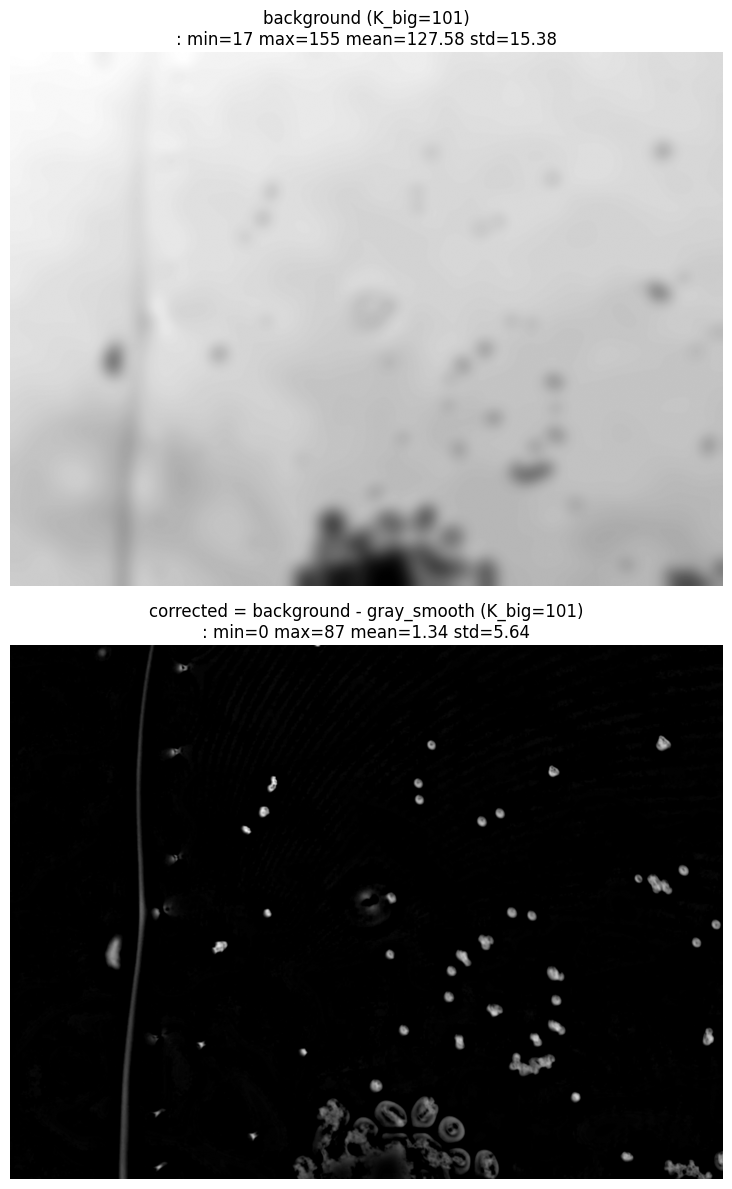

In [ ]:
K_big = 101  # smallest that worked similarly to larger values
background = cv2.GaussianBlur(gray_smooth, (K_big, K_big), 0)
corrected = cv2.subtract(background, gray_smooth)

show_column(
    [background, corrected],
    [f"background (K_big={K_big})\n{stats(background,'')}",
     f"corrected = background - gray_smooth (K_big={K_big})\n{stats(corrected,'')}"],
    figsize=(8, 12)
)

In [ ]:
# what's done so far:

In [ ]:
# Convert to grayscale
# Small Gaussian blur (noise smoothing)
# Large Gaussian blur (background estimation)
# Subtraction to remove illumination

In [ ]:
# Correlation analysis for multiple Gaussian kernels
corr_records = []

all_kernels = kernels + [k]   # uses existing 'kernels' and later 'k=21'

for kk in all_kernels:
    b = cv2.GaussianBlur(gray, (kk, kk), 0)
    corr_val = np.corrcoef(
        gray.astype(np.float32).ravel(),
        b.astype(np.float32).ravel()
    )[0, 1]

    corr_records.append({
        "kernel": kk,
        "correlation_gray_blur": corr_val
    })

df_corr = pd.DataFrame(corr_records).sort_values("kernel")
display(df_corr)

,kernel,correlation_gray_blur
0,3,0.998978
1,5,0.998301
2,7,0.997143
3,11,0.994559
4,21,0.984330


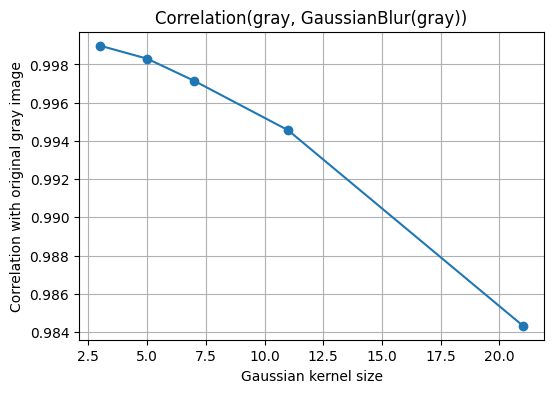

In [ ]:
plt.figure(figsize=(6,4))
plt.plot(df_corr["kernel"], df_corr["correlation_gray_blur"], marker="o")
plt.xlabel("Gaussian kernel size")
plt.ylabel("Correlation with original gray image")
plt.title("Correlation(gray, GaussianBlur(gray))")
plt.grid(True)
plt.show()

uint8 0 255


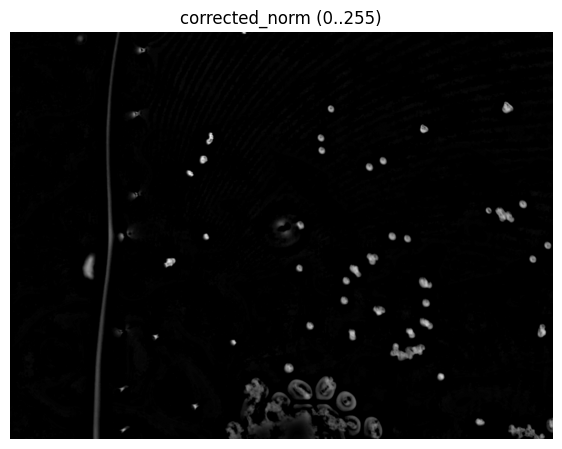

In [ ]:
corrected_norm = cv2.normalize(corrected, None, 0, 255, cv2.NORM_MINMAX)
print(corrected_norm.dtype, corrected_norm.min(), corrected_norm.max())
show(corrected_norm, "corrected_norm (0..255)", figsize=(7,7))

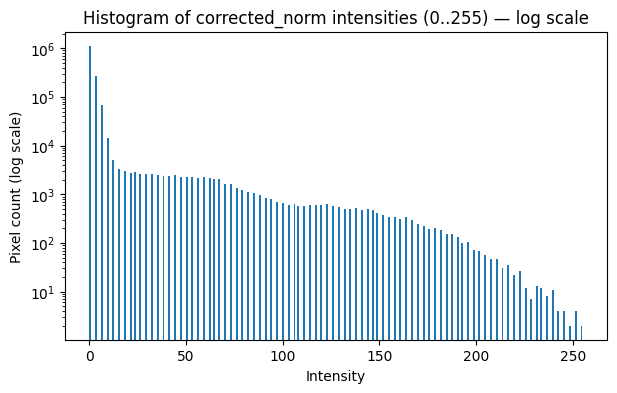

In [ ]:
plt.figure(figsize=(7,4))
plt.hist(corrected_norm.ravel(), bins=256, range=(0,255))

plt.yscale("log")  # log scale for pixel counts

plt.title("Histogram of corrected_norm intensities (0..255) — log scale")
plt.xlabel("Intensity")
plt.ylabel("Pixel count (log scale)")

plt.show()

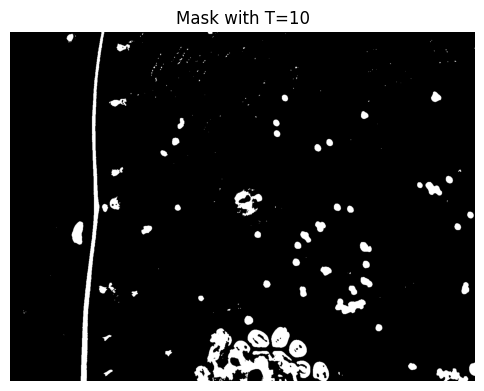

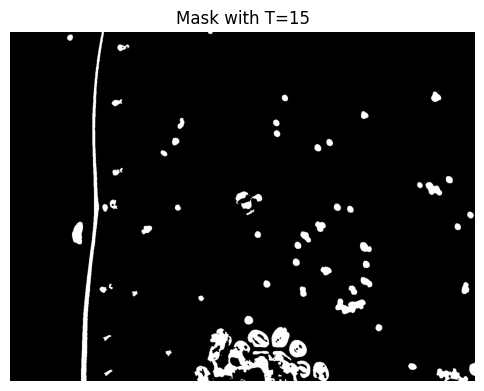

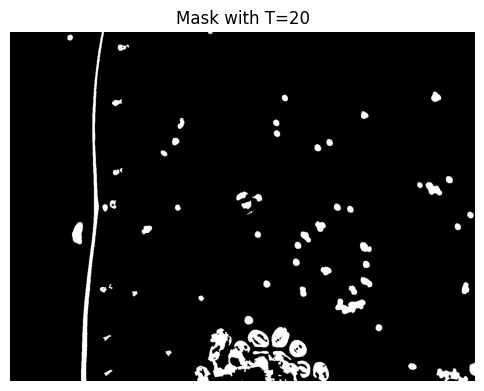

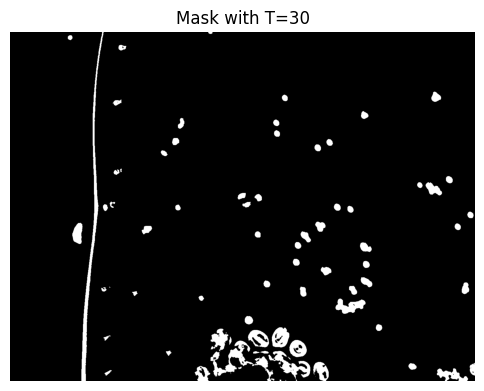

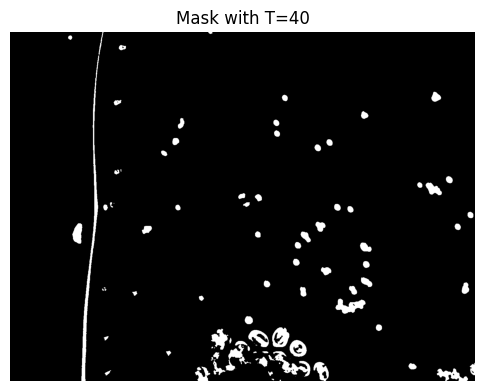

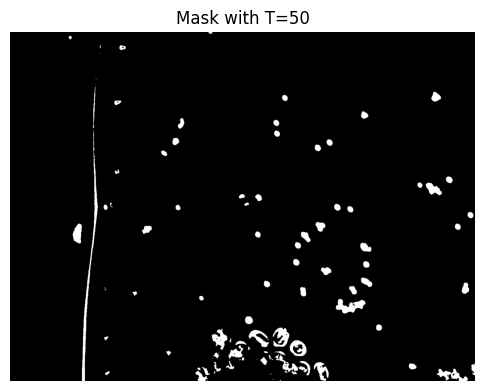

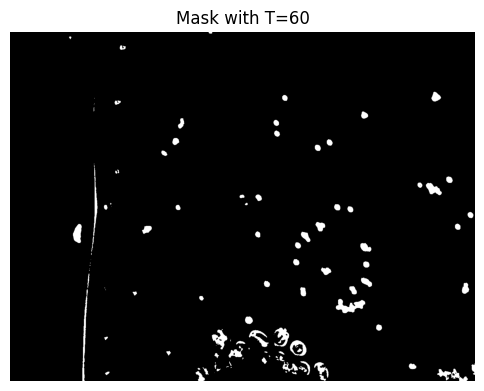

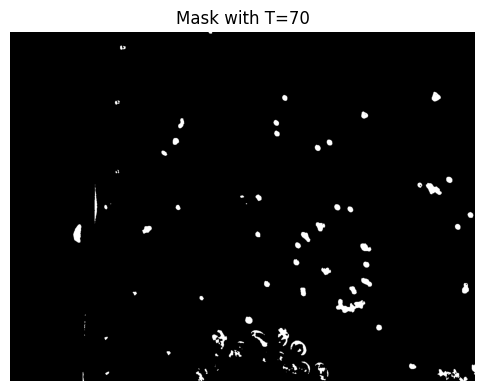

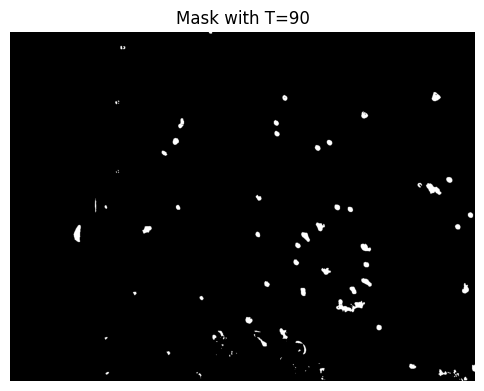

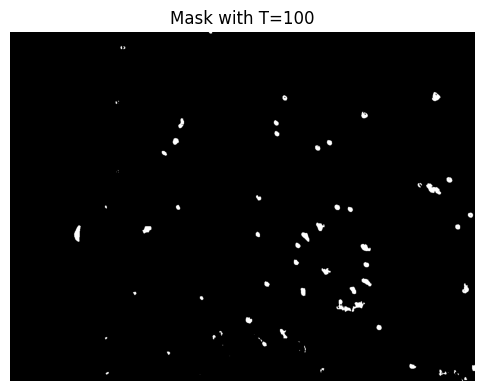

In [ ]:
for T in [10, 15, 20, 30, 40, 50, 60, 70, 90, 100]:
    _, mask = cv2.threshold(corrected_norm, T, 255, cv2.THRESH_BINARY)
    show(mask, f"Mask with T={T}", figsize=(6,6))

In [ ]:
# Threshold rule (per frame)
# percentile_keep = 99.5
# thr_value = float(np.percentile(corrected_norm, percentile_keep))

# _, binary_raw = cv2.threshold(corrected_norm, thr_value, 255, cv2.THRESH_BINARY)

# print(f"percentile_keep={percentile_keep} -> thr_value={thr_value:.2f}")
# show(binary_raw, f"binary_raw (percentile {percentile_keep}, T={thr_value:.1f})", figsize=(6,6))

In [ ]:
# Morphology cleanup
# kernel3 = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))

# binary_open = cv2.morphologyEx(binary_raw, cv2.MORPH_OPEN, kernel3, iterations=1)   # remove tiny noise
# binary_clean = cv2.morphologyEx(binary_open, cv2.MORPH_CLOSE, kernel3, iterations=1) # fill tiny gaps

# show_column(
#     [binary_raw, binary_open, binary_clean],
#     ["binary_raw", "binary_open (denoise)", "binary_clean (fill)"],
#     figsize=(8, 14)
# )

In [ ]:
# binary_roi = binary_clean.copy()
# left_margin_px = 0  # tune 10–60 if needed
# binary_roi[:, :left_margin_px] = 0

# show(binary_roi, f"binary_roi (left_margin_px={left_margin_px})", figsize=(6,6))

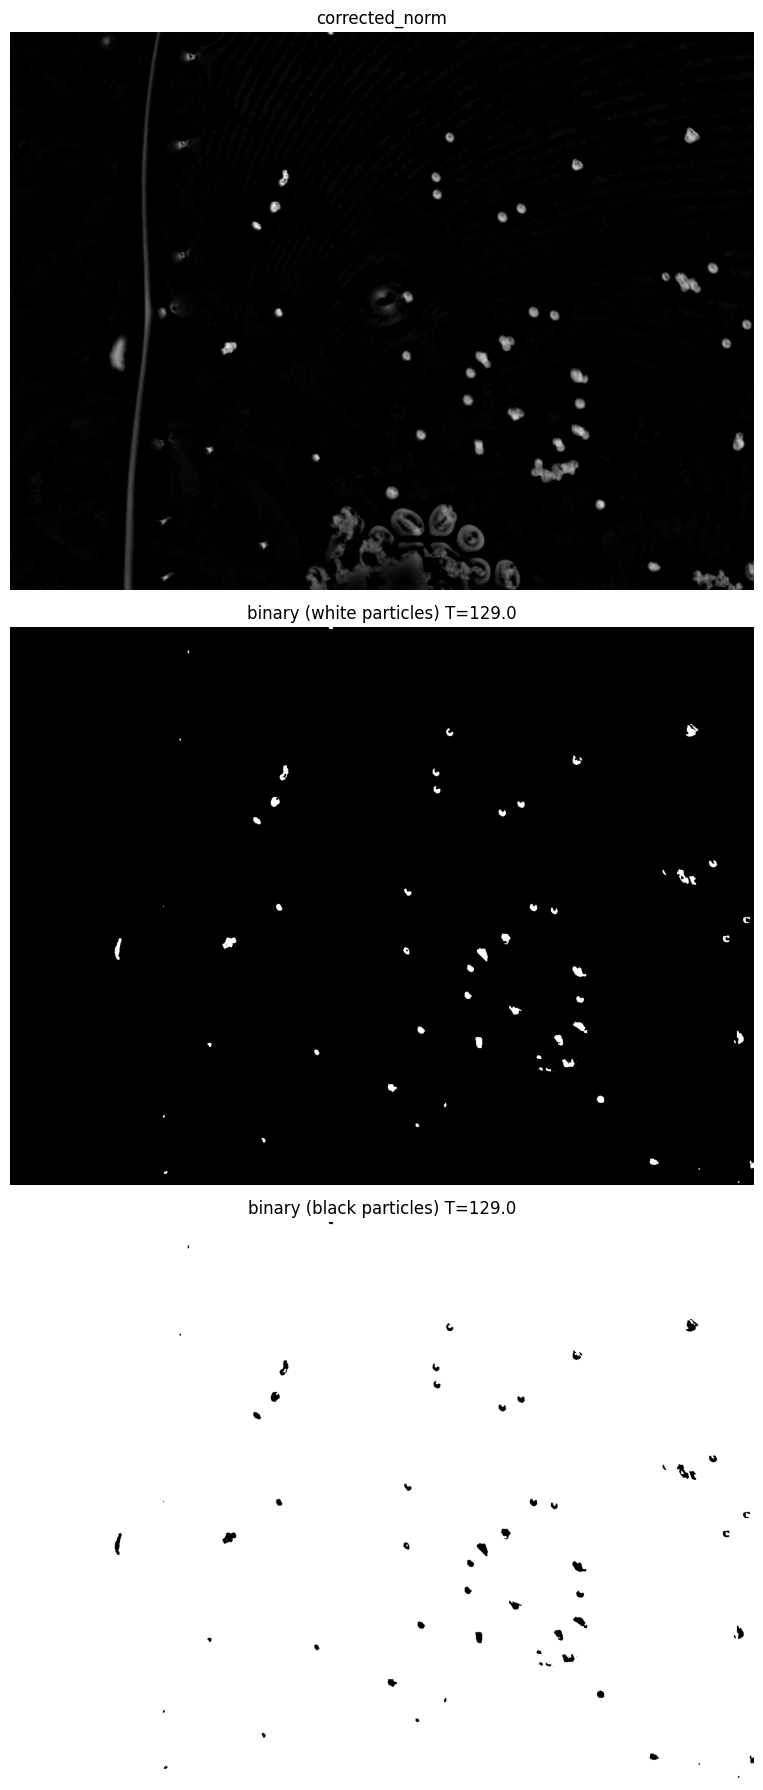

In [ ]:
# Choose threshold adaptively (percentile example)
percentile_keep = 99.5
T = np.percentile(corrected_norm, percentile_keep)

# White-particle binary
_, binary_white_1 = cv2.threshold(corrected_norm, T, 255, cv2.THRESH_BINARY)

# Black-particle binary (inverted)
_, binary_black = cv2.threshold(corrected_norm, T, 255, cv2.THRESH_BINARY_INV)

show_column(
    [corrected_norm, binary_white_1, binary_black],
    [f"corrected_norm", f"binary (white particles) T={T:.1f}", f"binary (black particles) T={T:.1f}"],
    figsize=(8, 18)
)

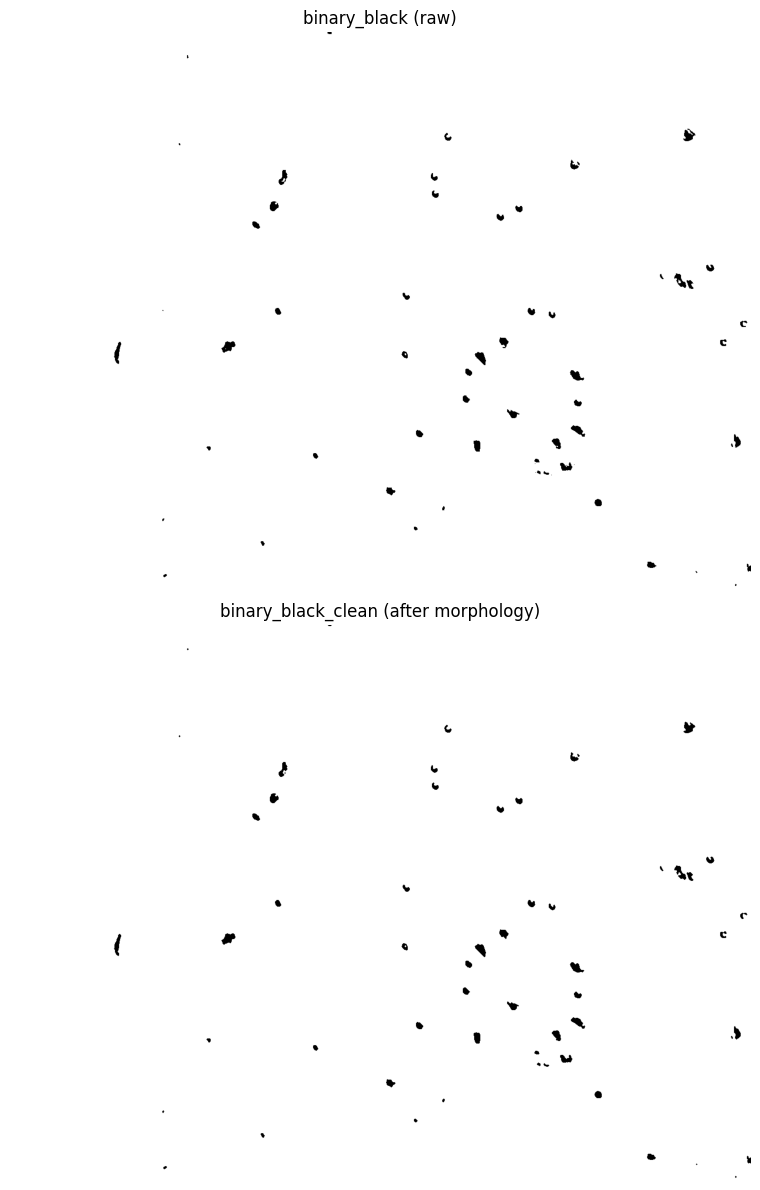

In [ ]:
# invert so foreground (particles) become white for morphology
binary_white = cv2.bitwise_not(binary_black)

kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3,3))
binary_white_open = cv2.morphologyEx(binary_white, cv2.MORPH_OPEN, kernel, iterations=1)
binary_white_clean = cv2.morphologyEx(binary_white_open, cv2.MORPH_CLOSE, kernel, iterations=1)

# invert back to black-particle convention
binary_black_clean = cv2.bitwise_not(binary_white_clean)

show_column(
    [binary_black, binary_black_clean],
    ["binary_black (raw)", "binary_black_clean (after morphology)"],
    figsize=(8, 12)
)

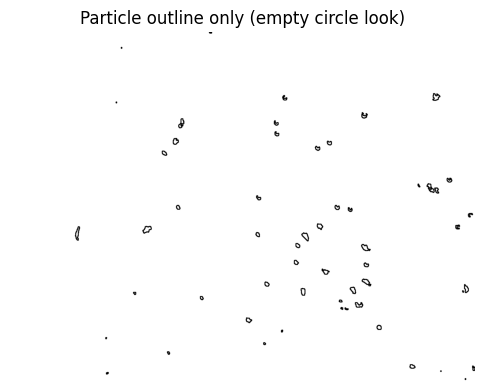

In [ ]:
contours, _ = cv2.findContours(binary_white_clean, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

outline = np.full_like(binary_black_clean, 255)  # white canvas
cv2.drawContours(outline, contours, -1, 0, thickness=2)  # draw black outline only

show(outline, "Particle outline only (empty circle look)", figsize=(6,6))

In [ ]:
particle_records = []

for i, cnt in enumerate(contours):
    area = float(cv2.contourArea(cnt))
    M = cv2.moments(cnt)
    if M["m00"] == 0:
        continue
    cx = float(M["m10"] / M["m00"])
    cy = float(M["m01"] / M["m00"])

    particle_records.append({"blob_id": i, "x": cx, "y": cy, "area": area})

df_frame = pd.DataFrame(particle_records).sort_values("area", ascending=False)
df_frame.head()

,blob_id,x,y,area
31,31,423.969325,610.524540,326.0
28,28,914.886872,631.917725,275.5
55,55,1318.636364,201.187273,275.0
26,26,1099.704887,667.141604,266.0
30,30,208.404570,622.989919,248.0
